<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_3_Loss_Given_Default_(LGD)_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loss Given Default (LGD) Modeling: Recovery Analytics & Downturn LGD**

Part 3 of the credit risk series. It requires the outputs of *Part 0: Credit Risk Data Foundation*.

---

* Project Overview & Data Source

Data Source: This project uses the Lending Club loan [dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club), prepared in Part 0. The modeling sample is the set of **charged-off loans**, where the amount still owed at default and the money recovered afterwards are both observed. State unemployment rates from [FRED](https://fred.stlouisfed.org/) link recoveries to the economic cycle.

The Business Question: *When a borrower defaults, what fraction of the outstanding balance does the lender finally lose? Which loan characteristics drive that loss? And how much larger is it in a recession?*

Expected credit loss is the product of three parameters:

$$EL = PD \times LGD \times EAD$$

Parts 1 and 2 modeled **PD**, and the profit simulation in Part 2 simply *assumed* LGD = 60%. This project replaces that assumption with an estimate. The distinction matters: a 10% PD with a 20% LGD (a well-secured mortgage) and a 10% PD with a 90% LGD (an unsecured personal loan) are completely different risks.

Objective: To estimate portfolio-level and loan-level LGD, benchmark statistical and machine-learning LGD models out of time, and derive a **downturn LGD** that feeds the stress test in Part 4.

---

* The Logic & Methodology

Realized LGD Construction: LGD is measured with the **workout approach**, the standard method for retail loans: the net recoveries are discounted back to the default date and compared with the exposure at default. Two data pitfalls are corrected before modeling:
* **Resolution bias.** Recent defaults have not finished recovering and would inflate LGD.
* **Leakage.** Information decided after default (debt settlements) is excluded.

Exploratory Analysis: We examine the bimodal LGD distribution and compare default-weighted with exposure-weighted averages, the two averages used in Basel and in accounting.

Model Benchmarking: Five models are compared on an **out-of-time** sample:
1. a grade-average lookup (benchmark);
2. OLS;
3. **fractional logit** (Papke & Wooldridge);
4. a **two-stage hurdle** model;
5. **LightGBM**.

Evaluation & Explainability: Models are judged on error, rank ordering (Spearman), portfolio calibration and a calibration-by-decile chart. SHAP values explain the LightGBM challenger.

Downturn LGD: A macro "satellite" model links LGD to state unemployment. The downturn LGD is obtained by evaluating it at a stressed unemployment rate, and it is saved for Part 4.

---

* Results & Business Impact

Portfolio LGD: Across **138,102 completed workouts**, the long-run average LGD is **91.2%** (default-weighted) and **91.3%** (exposure-weighted). **21.6%** of defaulted loans recover nothing at all. The fixed 60% LGD assumed in Part 2 therefore understated the loss on a defaulted Lending Club loan by about 31 percentage points.

Model Performance: The **two-stage hurdle model** ranks losses best out of time (Spearman 0.122, against 0.069 for the grade-average benchmark). All models explain only about **1% of loan-level variance**, and all are well calibrated at portfolio level (bias within ±0.6%). With LGD compressed between 85% and 100%, the value of loan-level modeling here is small.

Downturn Impact: LGD is clearly cyclical. Defaults in the highest-unemployment quarters lost **94.2%**, against **91.2%** otherwise (+3.0 pp, t = 8.5). The satellite model estimates **+0.34 pp of LGD per +1 pp of unemployment**, which gives a downturn LGD of **92.2–93.0%** at 10% unemployment, an add-on of about **1.5 pp**.

---

Tech Stack: Python, Pandas, NumPy, SciPy, Scikit-Learn, LightGBM, SHAP, Matplotlib, Google Colab.

# Step 1: Environment Setup & Data Loading
We mount Google Drive and load the three outputs of Part 0: the loan table, the state macro table and the snapshot date.

The key assumptions of the analysis are defined up front as constants, so their impact can be tested by changing one line and re-running:

* `WORKOUT_MONTHS`: average time from default to recovery. Lending Club does not report *when* recoveries were received, so this is an assumption.
* `MIN_MONTHS_SINCE_CO`: the minimum age of a charge-off for its recovery process to count as complete.
* `STRESS_UR`: the unemployment rate used for the downturn LGD.

In [ ]:
try:
    import shap
except ImportError:
    !pip install shap
    import shap
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy import stats
from scipy.special import expit, logit
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

# 1.2. Key assumptions (change and re-run to test sensitivity)
WORKOUT_MONTHS = 12        # average months from default to recovery cash flows
MIN_MONTHS_SINCE_CO = 18   # keep only charge-offs at least this old (completed workouts)
CO_LAG_MONTHS = 2          # Lending Club charges off ~150 DPD, about 2 months after our 90-DPD default date
STRESS_UR = 10.0           # unemployment rate (%) for the downturn LGD

# 1.3. Load the Part 0 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
macro_state = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_state_q.csv'))
macro_us = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_us_q.csv'))
with open(os.path.join(PROJECT_DIR, 'as_of.txt')) as f:
    AS_OF = pd.Period(f.read().strip(), 'M')

print(f"Loans loaded: {len(lc):,} | Snapshot date: {AS_OF}")
print(f"Charged-off loans: {(lc['exit_type'] == 'default').sum():,}")

Mounted at /content/drive
Loans loaded: 2,260,668 | Snapshot date: 2019-03
Charged-off loans: 269,360


# Step 2: Realized LGD Construction & Resolution Bias
Before any model is built, LGD must be *measured*. For a defaulted loan $i$:

$$EAD_i = \text{Funded}_i - \text{PrincipalRepaid}_i \qquad\qquad NR_i = \text{Recoveries}_i - \text{CollectionFee}_i$$

The **economic (workout) LGD** discounts the net recovery back to the default date, because money recovered a year after default is worth less than money today:

$$LGD_i = 1 - \frac{NR_i \,/\,(1+r_i)^{W/12}}{EAD_i}, \qquad LGD_i \in [0,1]$$

Here $r_i$ is the loan's contract interest rate (a common choice of discount rate) and $W$ is the workout length in months. With $W = 0$ we get the undiscounted "accounting" LGD.

**Resolution bias.** A loan charged off last month has had no time to recover anything. If we included it, LGD would look too high. We plot the average recovery rate against the time elapsed since charge-off. The curve rises and then flattens once workouts are complete. We keep only defaults beyond that point, which is exactly what banks do.

**Leakage.** `debt_settlement_flag` explains recoveries very well, but the settlement is agreed *after* default. At the moment we need the LGD prediction, it is unknown, so it is excluded from all models.

--- Building the Defaulted-Loan Sample ---


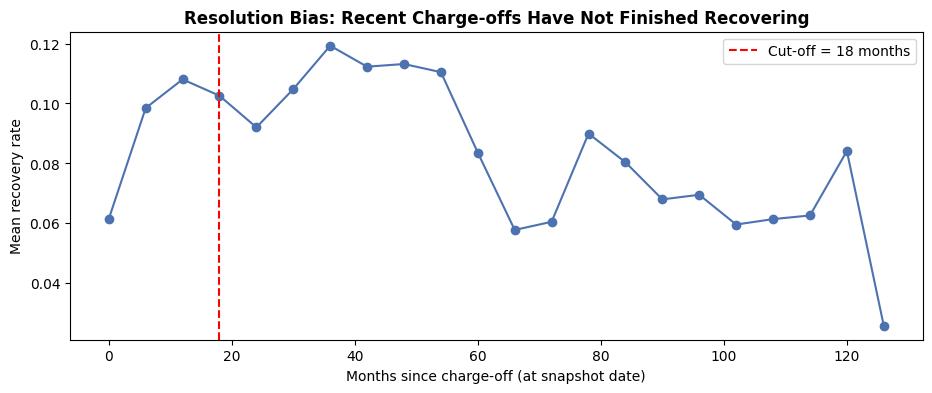

All defaults: 269,338 | Completed workouts kept: 138,102

--- Mean LGD by Assumed Workout Length (months) ---


,Mean LGD
0,0.8981
6,0.9053
12,0.9119
24,0.9237
36,0.9339


In [ ]:
print("--- Building the Defaulted-Loan Sample ---")

# 1. Defaulted loans with a positive exposure
d = lc[lc['exit_type'].eq('default') & (lc['ead'] > 0)].copy()
as_of_n = AS_OF.year * 12 + AS_OF.month
d['months_since_co'] = as_of_n - (d['exit_m'].dt.year * 12 + d['exit_m'].dt.month) - CO_LAG_MONTHS
d['rec_rate_raw'] = d['net_recovery'] / d['ead']
d['default_q'] = d['exit_m'].dt.asfreq('Q').astype(str)

# 2. Attach the economy at the time of default (state and US unemployment in the default quarter)
d = d.merge(macro_state[['state', 'quarter', 'ur']].rename(
        columns={'state': 'addr_state', 'quarter': 'default_q', 'ur': 'ur_default'}),
        on=['addr_state', 'default_q'], how='left')
d = d.merge(macro_us[['quarter', 'ur_us']].rename(columns={'quarter': 'default_q'}), on='default_q', how='left')

# 3. Resolution bias: recovery rate vs. months since charge-off
bins_ms = np.arange(0, d['months_since_co'].max() + 6, 6)
curve = (d.assign(bucket=pd.cut(d['months_since_co'], bins_ms, right=False))
          .groupby('bucket', observed=True)['rec_rate_raw'].mean())
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot([b.left for b in curve.index], curve.values, marker='o', color='#4C72B0')
ax.axvline(MIN_MONTHS_SINCE_CO, color='red', ls='--', label=f'Cut-off = {MIN_MONTHS_SINCE_CO} months')
ax.set_xlabel('Months since charge-off (at snapshot date)'); ax.set_ylabel('Mean recovery rate')
ax.set_title('Resolution Bias: Recent Charge-offs Have Not Finished Recovering', fontweight='bold')
ax.legend(); plt.show()

# 4. Keep completed workouts only and compute realized LGD
resolved = d[(d['months_since_co'] >= MIN_MONTHS_SINCE_CO) & d['ur_default'].notna()].copy()

def realized_lgd(frame, workout_months):
    discount = (1 + frame['int_rate'] / 100) ** (workout_months / 12)
    return (1 - frame['net_recovery'] / discount / frame['ead']).clip(0, 1)

resolved['lgd'] = realized_lgd(resolved, WORKOUT_MONTHS)
resolved['full_loss'] = (resolved['lgd'] >= 0.9999).astype(int)

print(f"All defaults: {len(d):,} | Completed workouts kept: {len(resolved):,}")

# 5. Sensitivity of the average LGD to the workout-length assumption
sens_w = pd.Series({w: realized_lgd(resolved, w).mean() for w in [0, 6, 12, 24, 36]})
print("\n--- Mean LGD by Assumed Workout Length (months) ---")
display(sens_w.to_frame('Mean LGD').round(4))

## Conclusion:
Realized LGD is now measured on a clean sample of **138,102 completed workouts**, out of 269,338 defaults with a positive exposure.

1. **Workouts finish quickly.** The mean recovery rate rises from about 6% for charge-offs less than 6 months old to about 10% at 6–12 months, and then stays on a plateau of roughly 9–12%. Most recovery cash therefore arrives within the first year. The 18-month cut-off is conservative: it keeps only workouts that are clearly complete.

2. **A cohort effect behind the curve.** Charge-offs older than about 5 years (defaults before 2014) recovered noticeably less, about 6–8%. This is not resolution bias, because those workouts are long finished. It reflects the period in which they defaulted: higher unemployment, and possibly different collection and debt-sale practices at a much smaller Lending Club. Step 7 returns to this.

3. **Discounting matters.** The mean LGD moves from **89.8%** (undiscounted, an implied recovery of about 10%) to **91.2%** with the 12-month base case and **93.4%** with a 36-month workout. Because the workout length is an assumption, this ±2 pp range must be reported with the final estimate.

# Step 3: Exploratory LGD Analysis
Banks report two different portfolio averages, and they answer different questions:

$$\overline{LGD}_{\text{default-weighted}} = \frac{1}{N}\sum_{i=1}^{N} LGD_i \qquad\qquad \overline{LGD}_{\text{exposure-weighted}} = \frac{\sum_i EAD_i \cdot LGD_i}{\sum_i EAD_i}$$

* The **default-weighted** average treats every default equally. Basel requires it for retail long-run average LGD.
* The **exposure-weighted** average is what the *dollar* loss depends on. If large loans lose more, it is higher.

We also look at the *shape* of the distribution, and at LGD by grade and over time against unemployment.

--- Portfolio LGD ---
Default-weighted LGD : 91.19%
Exposure-weighted LGD: 91.29%
Zero-recovery share (LGD = 100%): 21.57%


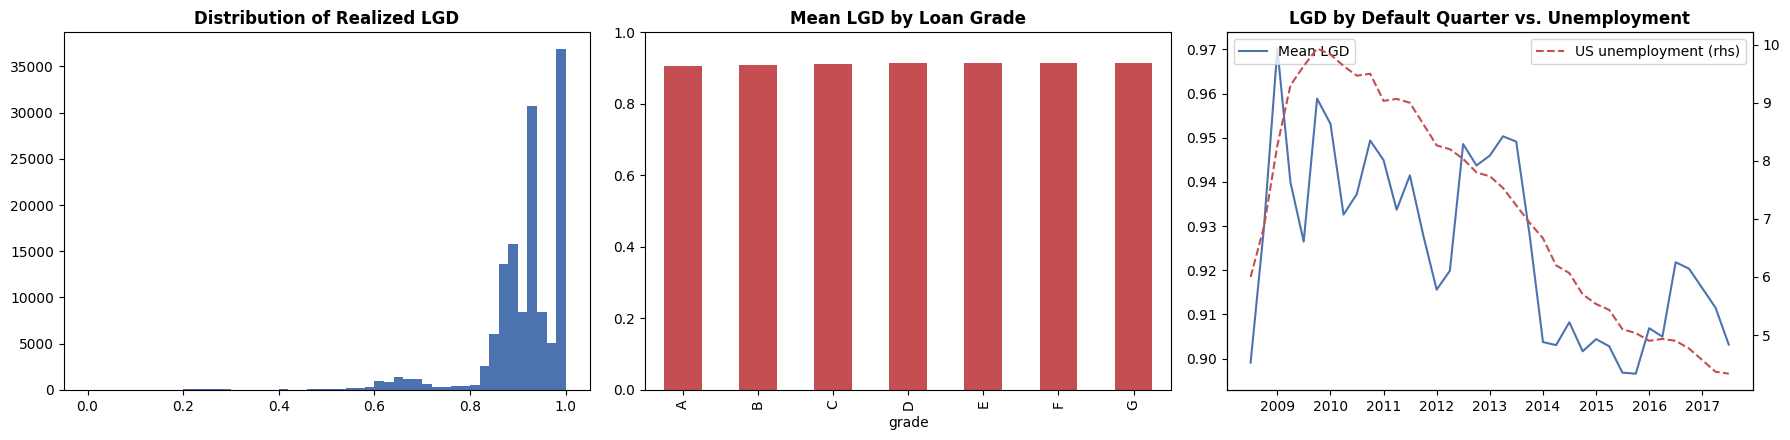


--- LGD by Term and Purpose ---


,mean,size
term_m,,
36,0.909755,84380
60,0.915291,53722


,mean,size
purpose,,
debt_consolidation,0.911615,86013
credit_card,0.912549,25378
other,0.910331,7901
home_improvement,0.912117,7507
small_business,0.918357,2752
major_purchase,0.915308,2607


In [ ]:
print("--- Portfolio LGD ---")
lra_dw = resolved['lgd'].mean()
lra_ew = np.average(resolved['lgd'], weights=resolved['ead'])
print(f"Default-weighted LGD : {lra_dw:.2%}")
print(f"Exposure-weighted LGD: {lra_ew:.2%}")
print(f"Zero-recovery share (LGD = 100%): {resolved['full_loss'].mean():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# 1. Distribution
axes[0].hist(resolved['lgd'], bins=50, color='#4C72B0')
axes[0].set_title('Distribution of Realized LGD', fontweight='bold')

# 2. LGD by grade
resolved.groupby('grade')['lgd'].mean().plot.bar(ax=axes[1], color='#C44E52')
axes[1].set_title('Mean LGD by Loan Grade', fontweight='bold'); axes[1].set_ylim(0, 1)

# 3. LGD over time vs. unemployment
ts = resolved.groupby('default_q').agg(lgd=('lgd', 'mean'), n=('lgd', 'size'), ur_us=('ur_us', 'first'))
ts = ts[ts['n'] >= 30]
x = pd.PeriodIndex(ts.index, freq='Q').to_timestamp()
axes[2].plot(x, ts['lgd'], color='#4C72B0', label='Mean LGD')
ax2 = axes[2].twinx(); ax2.plot(x, ts['ur_us'], color='#C44E52', ls='--', label='US unemployment (rhs)')
axes[2].set_title('LGD by Default Quarter vs. Unemployment', fontweight='bold')
axes[2].legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

print("\n--- LGD by Term and Purpose ---")
display(resolved.groupby('term_m')['lgd'].agg(['mean', 'size']))
display(resolved.groupby('purpose')['lgd'].agg(['mean', 'size']).sort_values('size', ascending=False).head(6))

## Conclusion:
1. **Level.** Lending Club loans are unsecured, and the LGD is very high: **91.2%** default-weighted and **91.3%** exposure-weighted. The two averages are almost equal, so loan size barely affects the loss rate. In dollars, a defaulted Lending Club loan returns only about 9 cents per dollar of exposure (after discounting). This replaces the 60% assumed in Part 2.

2. **Shape.** The distribution is not the textbook U-shape of secured lending. It is **J-shaped and compressed**: almost all loans sit between 85% and 100%, and **21.6%** recover nothing (LGD = 100%). There is no mass of low-loss loans, because there is no collateral.

3. **Weak segmentation.** Mean LGD barely varies by grade (90.7% for A to 91.6% for G), term (91.0% vs. 91.5%) or purpose (91.0–91.8%). PD and LGD do compound slightly, since riskier grades lose a little more. But the differences are small, which limits how much any loan-level model can explain.

4. **Clear cyclicality.** Over time, mean LGD tracks unemployment. It was 93–97% for defaults in 2009–2011, when US unemployment was 9–10%. It fell to about 90–91% in 2014–2016, as unemployment dropped to 5%. This is the first evidence that a downturn LGD is needed (Step 7).

# Algorithm Logic Review:
1. Segment Average (Benchmark)
Explanation: Predict each loan's LGD with the average LGD of its grade in the training data. It is transparent and common for small retail portfolios, and every other model must beat it.
Math:
$$\widehat{LGD}_i = \frac{1}{N_g}\sum_{j \in g(i)} LGD_j$$
Best Use: Portfolios with limited data, or as the regulatory "sanity check" benchmark.

2. Linear Regression (OLS)
Explanation: The simplest regression. It gives the best *linear* predictor, but it ignores that LGD is bounded in $[0,1]$: predictions can fall outside that range, the error variance is not constant, and the bimodal target breaks normal-error inference.
Math:
$$LGD_i = x_i'\beta + \varepsilon_i, \qquad \hat\beta = (X'X)^{-1}X'y$$
Best Use: A naive benchmark that shows why specialized LGD models are needed.

3. Fractional Logit (Papke & Wooldridge, 1996)
Explanation: Models the conditional *mean* of LGD with the logistic function, so predictions always stay between 0 and 1. It is estimated by maximizing the Bernoulli **quasi**-likelihood: the logistic-regression likelihood, but with a target that can take any value in $[0,1]$. The estimator is consistent as long as the mean is correctly specified (QMLE). Standard errors must be **robust (sandwich)**, because LGD is not a Bernoulli variable.
Math:
$$E[LGD_i \mid x_i] = \Lambda(x_i'\beta) = \frac{1}{1+e^{-x_i'\beta}}$$
$$\ell(\beta) = \sum_i \Big[ y_i \log \Lambda(x_i'\beta) + (1-y_i)\log\big(1-\Lambda(x_i'\beta)\big) \Big]$$
Algorithm (Newton–Raphson / IRLS): with $\mu = \Lambda(X\beta)$ and $W = \text{diag}\{\mu_i(1-\mu_i)\}$,
$$\beta^{(k+1)} = \beta^{(k)} + (X'WX)^{-1} X'(y-\mu), \qquad \widehat{V}(\hat\beta) = A^{-1}BA^{-1},\; A = X'WX,\; B = \textstyle\sum_i (y_i-\hat\mu_i)^2 x_i x_i'$$
Average marginal effect of feature $j$: $AME_j = \hat\beta_j \cdot \overline{\hat\mu(1-\hat\mu)}$.
Best Use: The industry-standard parametric LGD model. It is interpretable, bounded and easy to validate.

4. Two-Stage (Hurdle) Model
Explanation: Treats "nothing recovered" as a separate outcome, because the drivers of *whether* anything is recovered may differ from the drivers of *how much*. Stage 1 is a logistic regression for $P(LGD = 1)$. Stage 2 is a fractional logit for the LGD of loans with some recovery. The two are combined with the law of total expectation.
Math:
$$E[LGD \mid x] = P(LGD=1 \mid x)\cdot 1 + \big(1 - P(LGD=1 \mid x)\big)\cdot E[LGD \mid x, LGD<1]$$
Best Use: LGD distributions with a large spike at 0% or 100%, which is typical of unsecured retail credit.

5. LightGBM (Machine-Learning Challenger)
Explanation: A gradient-boosting ensemble of regression trees. Each new tree is fitted to the residuals of the previous ones, so the model captures non-linear effects and interactions automatically. The price is transparency, which SHAP values partly restore. Predictions are clipped to $[0,1]$.
Math:
$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x), \qquad h_m \approx \arg\min_h \sum_i \big(y_i - F_{m-1}(x_i) - h(x_i)\big)^2$$
Best Use: Large datasets with complex interactions. In a bank, typically the **challenger** model that benchmarks the interpretable champion.

# Step 4: Feature Engineering & Out-of-Time Split
All features must be **known at the moment of default**, because that is when the LGD prediction is needed:

* **Origination:** grade, term, interest rate, loan amount, income, DTI, FICO, revolving utilization, home ownership, purpose, employment length, verification status.
* **Loan history:** months on book at default, and the EAD ratio (share of principal still owed).
* **Economy:** state unemployment rate in the default quarter.

Numeric features are standardized with the *training-set* mean and standard deviation. A coefficient therefore measures the effect of +1 standard deviation.

The split is **out-of-time**: the earliest 70% of defaults (by default date) are used for training and the most recent 30% for testing. This mirrors real use, where a model built on past defaults predicts future ones. It also fixes a weakness of the random split used in Parts 1 and 2.

In [ ]:
print("--- Feature Engineering ---")

# 1. Engineered features
resolved['log_loan_amnt'] = np.log(resolved['funded_amnt'])
resolved['log_annual_inc'] = np.log1p(resolved['annual_inc'].clip(lower=0))
resolved['ead_ratio'] = resolved['ead'] / resolved['funded_amnt']   # share of principal still owed
resolved['term_60'] = (resolved['term_m'] == 60).astype(int)

NUM_FEATURES = ['int_rate', 'log_loan_amnt', 'log_annual_inc', 'dti', 'fico', 'revol_util',
                'emp_years', 'mob_exit', 'ead_ratio', 'ur_default', 'term_60']
CAT_FEATURES = ['grade', 'home_ownership', 'purpose', 'verification_status']

# 2. Out-of-time split
cutoff = resolved['exit_m'].quantile(0.70)
train = resolved[resolved['exit_m'] <= cutoff].copy()
test = resolved[resolved['exit_m'] > cutoff].copy()
print(f"Train: {len(train):,} defaults up to {cutoff} | Test: {len(test):,} defaults after {cutoff}")

# 3. Design matrix (statistics learned on the training set only -> no leakage)
class Design:
    """Imputes, standardizes and one-hot encodes using training-set statistics."""
    def __init__(self, frame, num, cat, min_count=200):
        self.num, self.cat = num, cat
        self.median = frame[num].median()
        filled = frame[num].fillna(self.median)
        self.mean, self.std = filled.mean(), filled.std().replace(0, 1)
        self.levels = {}
        for c in cat:
            counts = frame[c].fillna('missing').value_counts()
            self.levels[c] = counts[counts >= min_count].index.tolist()[1:]   # most frequent = reference
    def transform(self, frame):
        Z = (frame[self.num].fillna(self.median) - self.mean) / self.std
        parts = [pd.Series(1.0, index=frame.index, name='const'), Z]
        for c, lv in self.levels.items():
            col = frame[c].fillna('missing')
            parts.append(pd.DataFrame({f'{c}={l}': (col == l).astype(float) for l in lv}, index=frame.index))
        return pd.concat(parts, axis=1)

design = Design(train, NUM_FEATURES, CAT_FEATURES)
X_train, X_test = design.transform(train), design.transform(test)
y_train, y_test = train['lgd'].values, test['lgd'].values
print(f"Design matrix: {X_train.shape[1]} columns (incl. intercept)")

--- Feature Engineering ---
Train: 102,679 defaults up to 2017-01 | Test: 35,423 defaults after 2017-01
Design matrix: 33 columns (incl. intercept)


# Step 5: Model Benchmarking
We now fit the five models from the Algorithm Logic Review. Models 3 and 4 use a hand-written **IRLS** routine that follows the Newton–Raphson update and the sandwich covariance shown above. Writing it out makes the mathematics visible. It is equivalent to a GLM with a binomial family and robust standard errors in `statsmodels`.

Before using the routine on real data, we run a quick **sanity check**: we simulate data with known coefficients and confirm that the estimator recovers them.

In [ ]:
print("--- Fitting LGD Models ---")

def fit_logit_irls(X, y, max_iter=100, tol=1e-9, ridge=1e-8):
    """(Fractional) logistic regression by Newton-Raphson (IRLS) with robust standard errors.
    y can be binary (logit) or any value in [0, 1] (fractional logit)."""
    X = np.asarray(X, float); y = np.asarray(y, float)
    k = X.shape[1]
    beta = np.zeros(k); beta[0] = logit(np.clip(y.mean(), 1e-4, 1 - 1e-4))   # start at the mean
    def quasi_loglik(b):
        mu = np.clip(expit(X @ b), 1e-12, 1 - 1e-12)
        return np.sum(y * np.log(mu) + (1 - y) * np.log(1 - mu))
    ll_old = quasi_loglik(beta)
    for it in range(max_iter):
        mu = expit(X @ beta)
        gradient = X.T @ (y - mu)                                        # X'(y - mu)
        hessian = (X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k)   # X'WX
        step = np.linalg.solve(hessian, gradient)
        t = 1.0
        while quasi_loglik(beta + t * step) < ll_old - 1e-10 and t > 1e-4:   # step halving
            t /= 2
        beta = beta + t * step
        ll_new = quasi_loglik(beta)
        if np.max(np.abs(t * step)) < tol or abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new
    mu = expit(X @ beta)
    A_inv = np.linalg.inv((X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k))
    score = X * (y - mu)[:, None]
    V_robust = A_inv @ (score.T @ score) @ A_inv                         # sandwich A^-1 B A^-1
    return {'beta': beta, 'se_robust': np.sqrt(np.diag(V_robust)),
            'n_iter': it + 1, 'avg_dmu': np.mean(mu * (1 - mu))}

def predict_logit(fit, X):
    return expit(np.asarray(X, float) @ fit['beta'])

def coef_table(fit, names):
    z = fit['beta'] / fit['se_robust']
    return pd.DataFrame({'Coefficient': fit['beta'], 'Robust SE': fit['se_robust'], 'z': z,
                         'p-value': 2 * stats.norm.sf(np.abs(z)), 'AME': fit['beta'] * fit['avg_dmu']}, index=names)

# 0. Sanity check: recover known coefficients from simulated fractional data
rng = np.random.default_rng(0)
X_sim = np.column_stack([np.ones(20000), rng.normal(size=(20000, 2))])
mu_sim = expit(X_sim @ np.array([0.5, 1.0, -0.7]))
y_sim = rng.beta(5 * mu_sim, 5 * (1 - mu_sim))
print(f"Sanity check -> true [0.5, 1.0, -0.7], estimated {fit_logit_irls(X_sim, y_sim)['beta'].round(3)}\n")

preds = {}

# 1. Segment average (benchmark)
grade_avg = train.groupby('grade')['lgd'].mean()
preds['1. Grade Average (Benchmark)'] = test['grade'].map(grade_avg).fillna(train['lgd'].mean()).values

# 2. OLS
beta_ols, *_ = np.linalg.lstsq(X_train.values, y_train, rcond=None)
preds['2. OLS'] = X_test.values @ beta_ols
print(f"OLS predictions outside [0, 1]: {np.mean((preds['2. OLS'] < 0) | (preds['2. OLS'] > 1)):.2%}")

# 3. Fractional logit
frac_logit = fit_logit_irls(X_train, y_train)
preds['3. Fractional Logit'] = predict_logit(frac_logit, X_test)
print(f"Fractional logit converged in {frac_logit['n_iter']} Newton iterations")

# 4. Two-stage hurdle model
stage1 = fit_logit_irls(X_train, train['full_loss'].values)            # P(LGD = 1)
partial = train['full_loss'].values == 0
stage2 = fit_logit_irls(X_train[partial], y_train[partial])            # E[LGD | LGD < 1]
p_full = predict_logit(stage1, X_test)
preds['4. Two-Stage Hurdle'] = p_full + (1 - p_full) * predict_logit(stage2, X_test)

# 5. LightGBM challenger
lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                              min_child_samples=100, reg_lambda=1.0, random_state=42, verbose=-1)
def lgb_matrix(X):   # LightGBM does not accept spaces or special characters in feature names
    return X.drop(columns='const').rename(columns=lambda c: re.sub(r'[^0-9a-zA-Z_]', '_', c))
lgb_model.fit(lgb_matrix(X_train), y_train)
preds['5. LightGBM'] = np.clip(lgb_model.predict(lgb_matrix(X_test)), 0, 1)

# 6. What drives LGD? Fractional logit coefficients, sorted by average marginal effect
print("\n--- Fractional Logit: Drivers of LGD (AME = change in LGD per +1 SD / category) ---")
display(coef_table(frac_logit, X_train.columns).sort_values('AME', key=np.abs, ascending=False).round(4))

--- Fitting LGD Models ---
Sanity check -> true [0.5, 1.0, -0.7], estimated [ 0.501  1.01  -0.683]

OLS predictions outside [0, 1]: 0.01%
Fractional logit converged in 4 Newton iterations

--- Fractional Logit: Drivers of LGD (AME = change in LGD per +1 SD / category) ---


,Coefficient,Robust SE,z,p-value,AME
const,2.3326,0.0110,212.4665,0.0000,0.1865
grade=G,0.1931,0.0470,4.1044,0.0000,0.0154
grade=F,0.1777,0.0345,5.1453,0.0000,0.0142
grade=A,-0.1200,0.0310,-3.8709,0.0001,-0.0096
purpose=wedding,-0.1187,0.0918,-1.2937,0.1958,-0.0095
grade=E,0.1070,0.0222,4.8148,0.0000,0.0086
mob_exit,-0.1041,0.0131,-7.9452,0.0000,-0.0083
purpose=small_business,0.1007,0.0270,3.7250,0.0002,0.0081
int_rate,-0.0896,0.0137,-6.5520,0.0000,-0.0072
log_annual_inc,-0.0894,0.0050,-17.8024,0.0000,-0.0072


## Conclusion:
1. **The estimator works.** The sanity check recovers the true coefficients (0.501, 1.010, −0.683 vs. 0.5, 1.0, −0.7), which validates the IRLS implementation before it is applied to real data. The fractional logit then converged in **4 Newton iterations** on the 102,679 training defaults.

2. **OLS barely breaks the bounds here.** Only **0.01%** of OLS predictions fall outside [0, 1]. LGD is so concentrated near 91% that a linear model rarely reaches the boundaries. The theoretical weakness of OLS is real, but in this portfolio it has little practical impact.

3. **Drivers of LGD (average marginal effects).**
   * **Grade:** G (+1.5 pp) and F (+1.4 pp) lose most, and A the least (−1.0 pp), relative to grade C.
   * **Months on book at default:** −0.8 pp per standard deviation. Loans that default later, after more repayments and borrower "skin in the game", recover more.
   * **Borrower resources:** higher income (−0.7 pp per SD) and home ownership (own −0.6 pp, mortgage −0.5 pp) reduce LGD. Borrowers with assets are easier to collect from.
   * **Loan structure:** 60-month terms (+0.6 pp) and small-business loans (+0.8 pp) lose more.
   * **Economy:** state unemployment at default adds **+0.5 pp per SD** (z = 11.9), the strongest continuous macro signal.
   * FICO, DTI and revolving utilization are **not significant**. They predict *whether* a borrower defaults, not *how much* is recovered afterwards.

4. **Sign check.** One coefficient is counter-intuitive: `ead_ratio` (share of principal still owed) has a small *negative* effect (−0.3 pp). It is strongly correlated with `mob_exit` and the loan term, which carry the same information. In a production model, one of these overlapping variables would be removed.

# Step 6: Model Evaluation & Explainability
LGD models are evaluated on more than one dimension, because a bank uses them for more than one purpose:

| Metric | Formula / idea | Business question |
|---|---|---|
| RMSE, MAE | $\sqrt{\frac1N\sum(y-\hat y)^2}$, $\frac1N\sum\lvert y-\hat y\rvert$ | How large are loan-level errors? |
| Out-of-sample R² | $1-\sum(y-\hat y)^2/\sum(y-\bar y)^2$ | How much variation is explained? |
| Spearman ρ | rank correlation of $y$ and $\hat y$ | Does the model **rank** high-loss loans correctly? |
| Portfolio bias | $\sum EAD\cdot\hat y / \sum EAD\cdot y - 1$ | Is the total **dollar loss** calibrated? |

A realistic expectation: LGD models usually have a **low loan-level R²** (often below 0.2), even when they are useful. A large part of the recovery outcome is idiosyncratic: whether the borrower finds a job, or how the collection agency performs. Models are therefore judged mainly on ranking and on portfolio calibration.

--- Out-of-Time Model Evaluation ---


,RMSE,MAE,R2 (OOS),Spearman,Mean Predicted,Mean Actual,Portfolio Bias
4. Two-Stage Hurdle,0.1040,0.0663,0.0092,0.1224,0.9072,0.9111,-0.0057
2. OLS,0.1040,0.0662,0.0092,0.1208,0.9073,0.9111,-0.0058
3. Fractional Logit,0.1040,0.0662,0.0093,0.1207,0.9072,0.9111,-0.0059
5. LightGBM,0.1039,0.0654,0.0103,0.1082,0.9102,0.9111,-0.0020
1. Grade Average (Benchmark),0.1045,0.0639,0.0004,0.0685,0.9121,0.9111,-0.0007


Calculating SHAP values for LightGBM (this may take a moment)...


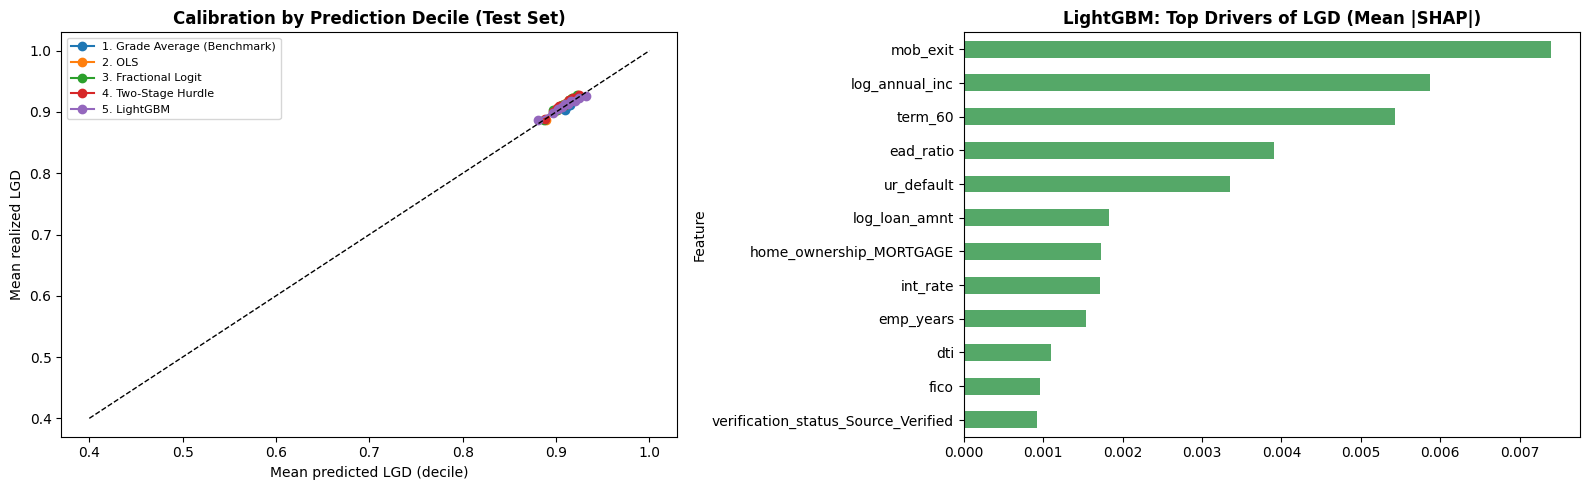

In [ ]:
print("--- Out-of-Time Model Evaluation ---")

def evaluate(y, p, ead):
    return {'RMSE': np.sqrt(np.mean((y - p) ** 2)),
            'MAE': np.mean(np.abs(y - p)),
            'R2 (OOS)': 1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2),
            'Spearman': stats.spearmanr(y, p).correlation,
            'Mean Predicted': p.mean(), 'Mean Actual': y.mean(),
            'Portfolio Bias': np.sum(ead * p) / np.sum(ead * y) - 1}

results_df = pd.DataFrame({m: evaluate(y_test, p, test['ead'].values) for m, p in preds.items()}).T
display(results_df.sort_values('Spearman', ascending=False).round(4))

# 1. Calibration by prediction decile
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, p in preds.items():
    decile = pd.qcut(pd.Series(p).rank(method='first'), 10, labels=False)
    cal = pd.DataFrame({'pred': p, 'actual': y_test, 'decile': decile}).groupby('decile').mean()
    axes[0].plot(cal['pred'], cal['actual'], marker='o', label=name)
lo = min(y_test.mean() - 0.3, 0.4)
axes[0].plot([lo, 1], [lo, 1], 'k--', lw=1)
axes[0].set_xlabel('Mean predicted LGD (decile)'); axes[0].set_ylabel('Mean realized LGD')
axes[0].set_title('Calibration by Prediction Decile (Test Set)', fontweight='bold'); axes[0].legend(fontsize=8)

# 2. SHAP explanation of the LightGBM challenger
print("Calculating SHAP values for LightGBM (this may take a moment)...")
X_test_sample = lgb_matrix(X_test).sample(min(2000, len(X_test)), random_state=42)
shap_values = shap.TreeExplainer(lgb_model).shap_values(X_test_sample)
shap_df = pd.DataFrame({'Feature': X_test_sample.columns,
                        'Mean Absolute SHAP': np.abs(shap_values).mean(axis=0)}).sort_values('Mean Absolute SHAP')
shap_df.tail(12).plot.barh(x='Feature', y='Mean Absolute SHAP', ax=axes[1], color='#55A868', legend=False)
axes[1].set_title('LightGBM: Top Drivers of LGD (Mean |SHAP|)', fontweight='bold')
plt.tight_layout(); plt.show()

## Conclusion:
Out-of-time results on **35,423 defaults** after January 2017:

| Model | Spearman ρ | RMSE | MAE | R² (OOS) | Portfolio Bias |
|---|---|---|---|---|---|
| 4. Two-Stage Hurdle | **0.122** | 0.1040 | 0.0663 | 0.9% | −0.57% |
| 2. OLS | 0.121 | 0.1040 | 0.0662 | 0.9% | −0.58% |
| 3. Fractional Logit | 0.121 | 0.1040 | 0.0662 | 0.9% | −0.59% |
| 5. LightGBM | 0.108 | **0.1039** | 0.0654 | **1.0%** | −0.20% |
| 1. Grade Average | 0.069 | 0.1045 | **0.0639** | 0.0% | **−0.07%** |

1. **Ranking.** The **two-stage hurdle model** ranks losses best (Spearman 0.122), closely followed by OLS and the fractional logit. All regression models almost double the ranking power of the grade-average benchmark (0.069). LightGBM does *not* beat the parametric models (0.108), so there is little non-linear structure left to capture.

2. **Low explanatory power.** Out-of-sample R² is about **1%** for every model. Most of the variation in recoveries depends on events after default: collection effort, debt-sale prices, the borrower's later situation. None of these is known at the moment of default. The RMSE improvement over the benchmark is only 0.0005.

3. **Calibration is good for all models.** Every model predicts the test-period average (91.1%) within 0.6%, and the decile points in the calibration chart lie on the 45° line. The grade average even has the lowest MAE, because predicting "about 91%" for everyone is hard to beat when LGD is this concentrated.

4. **Explainability confirms the specification.** LightGBM's SHAP ranking (months on book, income, 60-month term, EAD ratio, unemployment at default) closely matches the strongest drivers of the fractional logit. The challenger therefore supports the champion's variables and finds no hidden driver.

5. **Champion–challenger decision.** The **two-stage hurdle model** is the recommended champion: it has the best ranking, it is interpretable, and it is bounded. For portfolio-level uses such as provisioning and capital, however, a **segment-level LGD of about 91%** is almost as accurate, and much simpler to maintain and validate. That is a legitimate and common outcome for unsecured retail portfolios.

# Step 7: Downturn LGD & Macro Satellite Model
Regulators require LGD estimates that reflect **downturn conditions**, because recoveries tend to fall exactly when defaults rise. Borrowers have less income, collection is harder, and debt buyers pay less for charged-off loans. We use two approaches:

**Approach 1: observed downturn periods (Basel-style).** Compare the long-run average (LRA) LGD with the LGD of defaults in the worst unemployment quarters, and test the difference with a Welch t-test.

**Approach 2: macro satellite model.** A deliberately small fractional logit links LGD to the loan's grade and the state unemployment rate at default. Unemployment is kept in raw percentage points so that the coefficient transfers directly to the stress test:

$$E[LGD_i] = \Lambda\big(\alpha_{g(i)} + \gamma \cdot UR_{s(i),t(i)}\big), \qquad LGD^{downturn}_g = \Lambda\big(\hat\alpha_g + \hat\gamma \cdot UR^{*}\big)$$

The effect of +1 point of unemployment on LGD is $\partial LGD / \partial UR = \hat\gamma\,\Lambda(1-\Lambda)$.

**Conservatism rule:** a stress scenario must never *reduce* LGD. The downturn LGD is therefore floored at the LRA of each grade.

In [ ]:
print("--- Approach 1: Observed Downturn Periods ---")
quarter_ur = resolved.groupby('default_q')['ur_us'].first()
downturn_q = quarter_ur[quarter_ur >= quarter_ur.quantile(0.75)].index    # top quartile of unemployment
is_dt = resolved['default_q'].isin(downturn_q)
t_test = stats.ttest_ind(resolved.loc[is_dt, 'lgd'], resolved.loc[~is_dt, 'lgd'], equal_var=False)
print(f"Downturn quarters: {len(downturn_q)} ({is_dt.sum():,} defaults)")
print(f"LGD in downturn quarters: {resolved.loc[is_dt, 'lgd'].mean():.2%} | "
      f"other quarters: {resolved.loc[~is_dt, 'lgd'].mean():.2%} | Welch t = {t_test.statistic:.2f}, p = {t_test.pvalue:.3f}")

print("\n--- Approach 2: Macro Satellite Model ---")
grades = sorted(resolved['grade'].unique())
X_sat = pd.DataFrame({'const': 1.0, 'ur': resolved['ur_default']}, index=resolved.index)
for g in grades[1:]:
    X_sat[f'grade={g}'] = (resolved['grade'] == g).astype(float)
satellite = fit_logit_irls(X_sat, resolved['lgd'].values)
sat_table = coef_table(satellite, X_sat.columns)
display(sat_table.round(4))

gamma = sat_table.loc['ur', 'Coefficient']
p_gamma = sat_table.loc['ur', 'p-value']
alpha = {grades[0]: sat_table.loc['const', 'Coefficient']}
alpha.update({g: sat_table.loc['const', 'Coefficient'] + sat_table.loc[f'grade={g}', 'Coefficient'] for g in grades[1:]})
lra_by_grade = resolved.groupby('grade')['lgd'].mean()

downturn = pd.DataFrame({
    'LRA LGD': lra_by_grade,
    f'Model LGD @ UR = {STRESS_UR:.0f}%': {g: expit(a + gamma * STRESS_UR) for g, a in alpha.items()},
})
downturn['Downturn LGD (floored)'] = downturn.max(axis=1)
downturn['Add-on (pp)'] = 100 * (downturn['Downturn LGD (floored)'] - downturn['LRA LGD'])
print(f"\ngamma = {gamma:.4f} (p = {p_gamma:.3f}) -> +1pp unemployment raises LGD by "
      f"{100 * gamma * satellite['avg_dmu']:.2f} pp on average")
display(downturn.round(4))

# Save the satellite model for Part 4 (Stress Testing)
lgd_satellite = {
    'description': 'Fractional logit: LGD = expit(alpha_grade + gamma * state_UR_at_default_pct)',
    'alpha_by_grade': {g: float(a) for g, a in alpha.items()},
    'gamma_ur': float(gamma), 'gamma_p_value': float(p_gamma),
    'lra_by_grade': {g: float(v) for g, v in lra_by_grade.items()},
    'lra_default_weighted': float(lra_dw), 'lra_exposure_weighted': float(lra_ew),
    'workout_months': WORKOUT_MONTHS}
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json'), 'w') as f:
    json.dump(lgd_satellite, f, indent=2)
print("Saved lgd_satellite.json to Google Drive for Part 4.")

--- Approach 1: Observed Downturn Periods ---
Downturn quarters: 10 (1,513 defaults)
LGD in downturn quarters: 94.16% | other quarters: 91.16% | Welch t = 8.52, p = 0.000

--- Approach 2: Macro Satellite Model ---


,Coefficient,Robust SE,z,p-value,AME
const,2.0521,0.0252,81.3771,0.0000,0.1648
ur,0.0422,0.0033,12.7989,0.0000,0.0034
grade=B,0.0376,0.0202,1.8629,0.0625,0.0030
grade=C,0.0622,0.0193,3.2152,0.0013,0.0050
grade=D,0.0814,0.0196,4.1610,0.0000,0.0065
grade=E,0.0937,0.0201,4.6633,0.0000,0.0075
grade=F,0.0997,0.0222,4.4799,0.0000,0.0080
grade=G,0.1109,0.0296,3.7491,0.0002,0.0089



gamma = 0.0422 (p = 0.000) -> +1pp unemployment raises LGD by 0.34 pp on average


,LRA LGD,Model LGD @ UR = 10%,Downturn LGD (floored),Add-on (pp)
A,0.9070,0.9223,0.9223,1.5308
B,0.9099,0.9250,0.9250,1.5083
C,0.9114,0.9267,0.9267,1.5261
D,0.9130,0.9279,0.9279,1.4939
E,0.9139,0.9288,0.9288,1.4890
F,0.9145,0.9292,0.9292,1.4673
G,0.9156,0.9299,0.9299,1.4334


Saved lgd_satellite.json to Google Drive for Part 4.


## Conclusion:
1. **Observed downturn.** In the 10 highest-unemployment quarters (**1,513 defaults**, mostly 2009–2011), LGD averaged **94.2%**, against **91.2%** in all other quarters. The difference of **+3.0 pp** is highly significant (Welch t = 8.52, p < 0.001). The downturn sample is small, however, and comes from Lending Club's early years, so it may also reflect different collection practices.

2. **Satellite model.** With grade held fixed, each +1 pp of state unemployment raises LGD by **0.34 pp** ($\hat\gamma$ = 0.042, z = 12.8). At 10% unemployment, the model LGD is **92.2% (grade A) to 93.0% (grade G)**, a downturn add-on of about **1.4–1.5 pp** over each grade's long-run average. Since $\hat\gamma$ is positive and significant, the stress test in Part 4 uses it directly: PD and LGD rise together in a recession.

3. **Two estimates, one direction.** The observed downturn gap (+3.0 pp) is about twice the model add-on (+1.5 pp). The difference comes from the early-cohort effect seen in Step 2. A conservative bank would take the higher figure as its downturn LGD, about **94%**. The satellite model is the better tool for *scenario projection*, because it scales smoothly with the unemployment path.

# Executive Summary

This project replaced the fixed 60% LGD assumption of Part 2 with a measured and modeled Loss Given Default for **138,102 charged-off Lending Club loans** with completed workouts. It benchmarked five LGD models out of time and derived a downturn LGD for stress testing.

## Realized LGD

* **Level:** The long-run average LGD is **91.2%** (default-weighted) and **91.3%** (exposure-weighted), with a sensitivity range of 89.8–93.4% depending on the assumed workout length. The fixed 60% assumed in Part 2 understated the loss per defaulted loan by about 31 pp.
* **Shape:** The distribution is J-shaped and compressed between 85% and 100%. **21.6%** of defaults recover nothing.
* **Data corrections:** Charge-offs less than 18 months old were excluded to remove resolution bias. Post-default settlement information was excluded as leakage.

## Model Performance (Out-of-Time, 35,423 defaults)

| Rank | Model | Spearman ρ | RMSE | Portfolio Bias |
| --- | --- | --- | --- | --- |
| 1 | Two-Stage Hurdle | 0.122 | 0.1040 | −0.57% |
| 2 | OLS | 0.121 | 0.1040 | −0.58% |
| 3 | Fractional Logit | 0.121 | 0.1040 | −0.59% |
| 4 | LightGBM | 0.108 | 0.1039 | −0.20% |
| 5 | Grade Average (Benchmark) | 0.069 | 0.1045 | −0.07% |

> **Key Takeaway:** The two-stage hurdle model is the champion for ranking, and LightGBM confirms it misses no hidden non-linear structure. But all models explain only about 1% of loan-level variance. For an unsecured portfolio where every default loses about 91%, the business value lies in the **level** and **cyclicality** of LGD, not in loan-level differentiation.

---

## Downturn LGD

* **Macro sensitivity:** +1 pp state unemployment → **+0.34 pp LGD** (p < 0.001).
* **Observed downturn:** defaults in high-unemployment quarters lost **94.2%** vs. 91.2% (+3.0 pp).
* **Downturn LGD at 10% unemployment:** **92.2–93.0%** by grade (add-on ≈ 1.5 pp), saved to Drive and used in Part 4.

## Limitations

1. **Recovery timing is not observed.** Discounting relies on an assumed workout length, which moves LGD by ±2 pp.
2. **Recoveries reflect Lending Club's debt-sale and collection strategy**, not only borrower behavior. That strategy may have changed as the company grew.
3. **EAD excludes accrued interest and fees**, which understates the true economic loss.
4. **Thin downturn evidence.** Only 1,513 resolved defaults come from the high-unemployment quarters of 2009–2011.